Customer Churn Prediction Using ML(Machine Learning)

The project compares logistic regression, decision tree, and random forest models using accuracy, precision, recall and F1-score followed by hyperparameter tuning to improve model performance

In [2]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("churn_bigml_80.csv")
df.head(5)



,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
print("Dataset shape:", df.shape)
df.info()


Dataset shape: (2666, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night ch

In [5]:
df.isnull().sum()
df.duplicated().sum()


0

In [6]:
#Separate the target from the features
x = df.drop("Churn", axis=1)
y = df["Churn"]
print("Features:", x.shape)
print("Target:", y.shape)


Features: (2666, 19)
Target: (2666,)


In [7]:
#Split the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Training Features:", x_train.shape)
print("Testing Features:", x_test.shape)

Training Features: (2132, 19)
Testing Features: (534, 19)


In [8]:
#Preprocessing the data
categorical_cols = x.select_dtypes(include=['object']).columns
numerical_cols = x.select_dtypes(exclude=['object']).columns

print("Categorical columns:")
print(list(categorical_cols))
print("Numerical columns:")
print(list(numerical_cols))

Categorical columns:
['State', 'International plan', 'Voice mail plan']
Numerical columns:
['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


In [9]:
#Preproceesing the pipeline
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

#first model pipeline - Logistic Regression
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])
logistic_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Account length', 'Area code', 'Number vmail messages',
       'Total day minutes', 'Total day calls', 'Total day charge',
       'Total eve minutes', 'Total eve calls', 'Total eve charge',
       'Total night minutes', 'Total night calls', 'Total night charge',
       'Total intl minutes', 'Total intl calls', 'Total intl charge',
       'Customer service calls'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['State', 'International plan', 'Voice mail plan'], dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [10]:
 #make predictions
y_pred_logistic = logistic_pipeline.predict(x_test)
print(y_pred_logistic[:20])
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred_logistic})
comparison.head(20)


[False False False False False False False False False False False  True
 False False  True False False False False False]


,Actual,Predicted
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
5,False,False
6,False,False
7,False,False
8,False,False
9,False,False


In [11]:
#Evaluate the model
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")


Logistic Regression Model Evaluation:
Accuracy: 0.843
Precision: 0.425
Recall: 0.218
F1-Score: 0.288


MODEL 2 - DECISION TREE MODEL


In [12]:
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])
decision_tree_pipeline.fit(x_train, y_train)
y_pred_tree = decision_tree_pipeline.predict(x_test)
#Evaluate the Decision Tree model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
print("Decision Tree Model Evaluation:")
print(" ")
print(f"Accuracy: {accuracy_tree:.3f}")
print(f"Precision: {precision_tree:.3f}")
print(f"Recall: {recall_tree:.3f}")
print(f"F1-Score: {f1_tree:.3f}")


Decision Tree Model Evaluation:
 
Accuracy: 0.906
Precision: 0.679
Recall: 0.679
F1-Score: 0.679


MODEL 3 - RANDOM FOREST


In [13]:
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])
random_forest_pipeline.fit(x_train, y_train)
y_pred_rf = random_forest_pipeline.predict(x_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

COMPARING THE THREE MODELS


In [14]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf
    ],
    "F1-score": [
        f1,
        f1_tree,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.842697,0.425000,0.217949,0.288136
1,Decision Tree,0.906367,0.679487,0.679487,0.679487
2,Random Forest,0.932584,0.977273,0.551282,0.704918


In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(random_forest_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation F1-score:")
print(grid_search.best_score_)

# --- Evaluate the tuned model ---
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(x_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("\nTuned Random Forest")
print("-------------------")
print(f"Accuracy:  {accuracy_tuned:.3f}")
print(f"Precision: {precision_tuned:.3f}")
print(f"Recall:    {recall_tuned:.3f}")
print(f"F1-score:  {f1_tuned:.3f}")

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best Cross-Validation F1-score:
0.7393443107199842

Tuned Random Forest
-------------------
Accuracy:  0.934
Precision: 0.978
Recall:    0.564
F1-score:  0.715


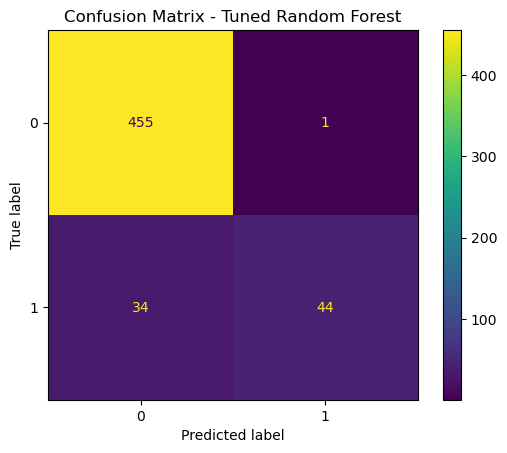

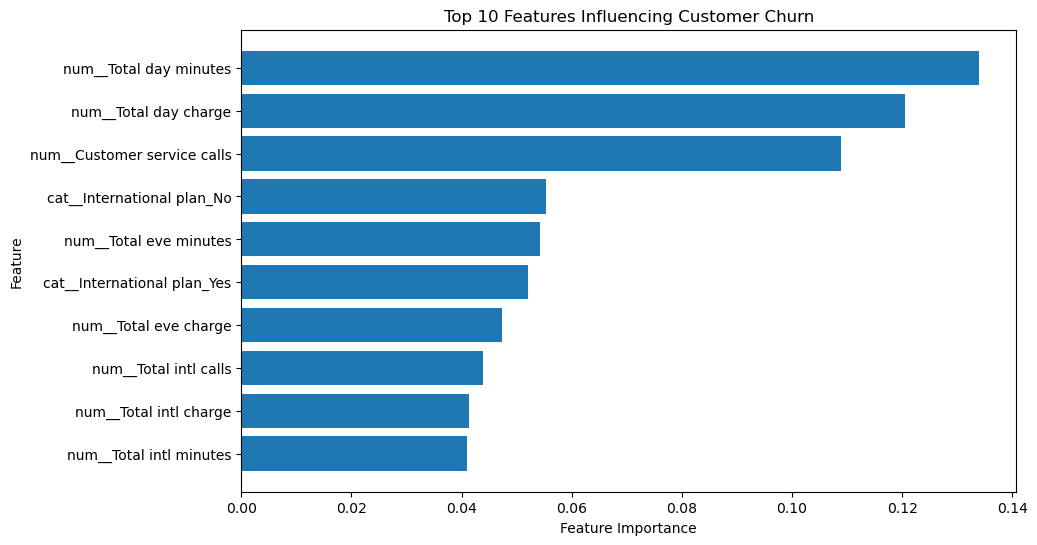

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()


preprocessor_fitted = best_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)


plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"].head(10)[::-1],
    importance_df["Importance"].head(10)[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Customer Churn")

plt.show()